In [1]:
from ribasim import run_ribasim
from ribasim import Model, Node
from ribasim.nodes import basin, flow_boundary, tabulated_rating_curve, user_demand
from shapely.geometry import Point
from pathlib import Path
import plotly.express as px
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
import pandas as pd 

In [2]:
# Tunsbergdalsvatn inflow
data_inflow = pd.read_csv("tunsberg_inflow_2.csv", sep=";")
data_inflow["time2"] = pd.to_datetime(data_inflow["time2"], dayfirst=True)
print(data_inflow)

                  time     inflow               time2    inflow2  turbine
0     09.10.2018 00:00  10.072869 2018-09-12 00:00:00  24.676908     29.1
1     09.10.2018 01:00   9.976292 2018-09-12 01:00:00  25.205465     29.1
2     09.10.2018 02:00   9.880606 2018-09-12 02:00:00  25.738100     29.1
3     09.10.2018 03:00   9.786343 2018-09-12 03:00:00  26.273488     29.1
4     09.10.2018 04:00   9.693910 2018-09-12 04:00:00  26.810658     29.1
...                ...        ...                 ...        ...      ...
1196               NaN        NaN 2018-10-31 20:00:00   1.537832     11.4
1197               NaN        NaN 2018-10-31 21:00:00   1.530498     11.4
1198               NaN        NaN 2018-10-31 22:00:00   1.523202     11.4
1199               NaN        NaN 2018-10-31 23:00:00   1.515946     11.4
1200               NaN        NaN 2018-11-01 00:00:00   1.508730      0.0

[1201 rows x 5 columns]


In [3]:
# Turbine discharge Leirdøla power plant
starttime = "2018-09-12 00:00"
endtime = "2018-11-01 00:00"

discharge = data_inflow["turbine"]

turbine_discharge = pd.DataFrame({
      "time": pd.date_range(start=starttime, end=endtime, freq="h"),
      "discharge": discharge
})     

In [4]:
project_dir = Path(".")
output_dir = project_dir / "output"
output_dir.mkdir(exist_ok=True)

model = Model(
    starttime=starttime,
    endtime=endtime,
    crs="EPSG:4326",
)


In [5]:
inflow = model.flow_boundary.add(
    Node(1, Point(0,2), name="Tunsbergdalsvatn_inflow"),
    [
        flow_boundary.Time(
            time=data_inflow["time2"],
            flow_rate=data_inflow["inflow2"],
        )
    ],
)

reservoir = model.basin.add(
    Node(2, Point(0,0), name="Tunsbergdalsvatn"),
    [
        basin.Profile(
            level=[465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 478.2, 478.4, 478.6, 478.8, 479],
            # area=[6435000, 6583000, 6717000, 6837999.99999999, 6968033.33333334,
            #        7108699.25093638, 7269467.41573043, 7413949.99999996,
            #        7522849.99999989, 7579000.00000001, 7618190.47619056, 7644809.52380944,
            #        7665133.33333333, 7679161.90476123, 7699485.71428504,7719809.52380885,7740133.33333266
            #         ], # last 3 values extrapolated linearly from the last 4 valid points up until and including 478. 
            area=[6435000, 6583000, 6717000, 6837999.99999999, 6968033.33333334,
                   7108699.25093638, 7269467.41573043, 7413949.99999996,
                   7522849.99999989, 7579000.00000001, 7618190.47619056, 7644809.52380944,
                   7665133.33333333, 7760015.38, 7768249.97, 7776045.08, 7783650.84, 7791032.56, 7798512.84
                    ], #
        ),
        basin.State(
            level=[477.692],  # initial level
        ),
        basin.Time(
            time=[starttime, endtime]
        ),
    ],
)

split1 = model.junction.add(
    Node(3, Point(0,-1), name="split2")
)

h = np.linspace(478.001, 479.0, 20)
Q = 200*(h-478)**(1.5)

spillway = model.tabulated_rating_curve.add(
    Node(4, Point(-1,-2), name = "Tunsbergdalsvatn_spillway"),
    [
        tabulated_rating_curve.Static(
            level=[478] + h.tolist(),
            flow_rate=[0.0] + Q.tolist(),
        )
    ],
)

split2 = model.junction.add(
    Node(5, Point(2, -2), name="split2")
)

turbine = model.user_demand.add(
    Node(6, Point(1, -3), name="Leirdola_turbine"),
    [
        user_demand.Time(
            demand=data_inflow["turbine"].values,  
            time=data_inflow["time2"],
            return_factor=0.0,  
            min_level=440,  
            demand_priority=1,
        )
    ],
)

gate = model.user_demand.add(
    Node(7, Point(3, -3), name="gate"),
    [
        user_demand.Time(
            demand = [0]*len(data_inflow["turbine"]),
            time=data_inflow["time2"],
            return_factor=0.0,  
            min_level=440,  
            demand_priority=1,
        )
    ],
)

sea = model.terminal.add(Node(8, Point(0, -5), name="sea"))

<Axes: >

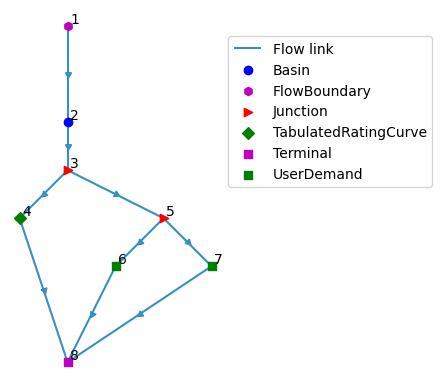

In [6]:
model.link.add(inflow, reservoir, name="inflow")
model.link.add(reservoir, split1) 
model.link.add(split1, spillway, name="spillway")
model.link.add(spillway, sea)
model.link.add(split1, split2)
model.link.add(split2, turbine, name="turbine")
model.link.add(split2, gate, name="gate")
model.link.add(turbine, sea)
model.link.add(gate, sea)
model.plot() 

In [9]:
toml_path = "Leirdøla_simple/ribasim.toml"
#model.write(toml_path)
cli_path = "ribasim.exe"
run_ribasim(toml_path, cli_path=cli_path, threads=1)

FileNotFoundError: Ribasim CLI executable not found at 'None'. Please ensure the path is correct.

In [21]:
df_reservoir = pd.read_feather("Leirdøla_simple/results/basin.arrow")


df_flow = pd.read_feather("Leirdøla_simple/results/flow.arrow")

print(df_flow)

                     time  link_id  from_node_id  to_node_id  flow_rate  \
0     2018-09-12 00:00:00        1             1           2  24.676908   
1     2018-09-12 00:00:00        2             2           3  29.100000   
2     2018-09-12 00:00:00        3             3           4   0.000000   
3     2018-09-12 00:00:00        4             4           8   0.000000   
4     2018-09-12 00:00:00        5             3           5  29.100000   
...                   ...      ...           ...         ...        ...   
10795 2018-10-31 23:00:00        5             3           5  11.399927   
10796 2018-10-31 23:00:00        6             5           6  11.399927   
10797 2018-10-31 23:00:00        7             5           7  11.399927   
10798 2018-10-31 23:00:00        8             6           8   0.000000   
10799 2018-10-31 23:00:00        9             7           8   0.000000   

        convergence  
0               NaN  
1      3.252301e-01  
2      0.000000e+00  
3      0.00

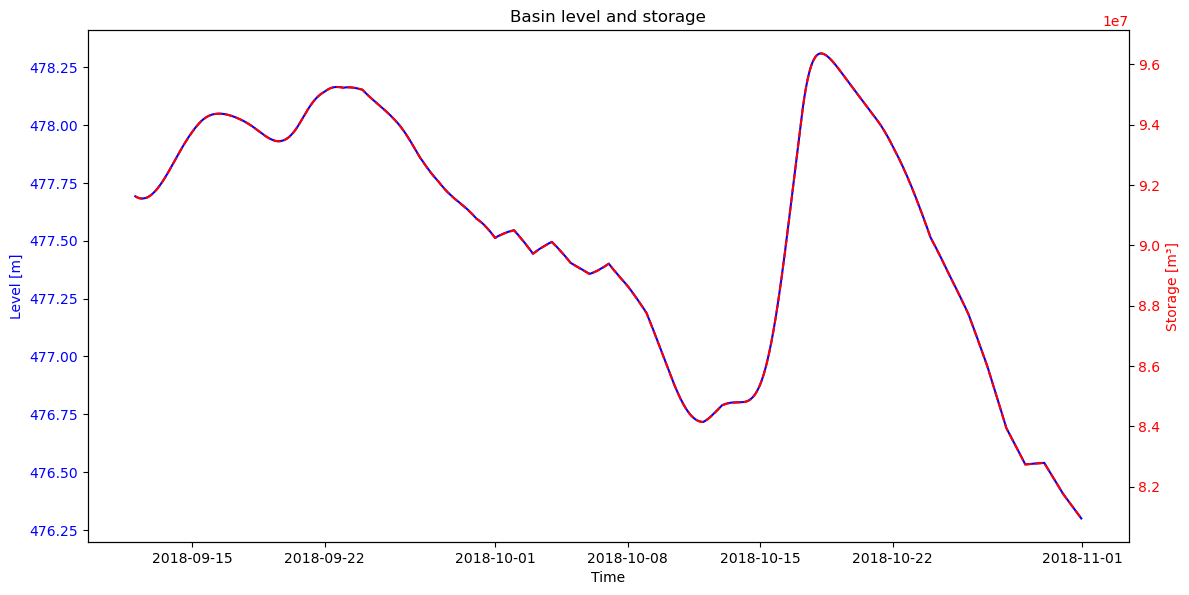

In [23]:
df_basin = pd.read_feather("Leirdøla_simple/results/basin.arrow")

# Create pivot tables and plot for Basin data
df_basin_wide = df_basin.pivot_table(
    index="time", columns="node_id", values=["storage", "level"]
)

# Plot level and storage on the same graph with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot level on the primary y-axis
color = "b"
ax1.set_xlabel("Time")
ax1.set_ylabel("Level [m]", color=color)
ax1.plot(df_basin_wide.index, df_basin_wide["level"], color=color)
ax1.tick_params(axis="y", labelcolor=color)

# Create a secondary y-axis for storage
ax2 = ax1.twinx()
color = "r"
ax2.set_ylabel("Storage [m³]", color="r")
ax2.plot(df_basin_wide.index, df_basin_wide["storage"], linestyle="--", color=color)
ax2.tick_params(axis="y", labelcolor=color)

fig.tight_layout()  # Adjust layout to fit labels
plt.title("Basin level and storage")
plt.show()

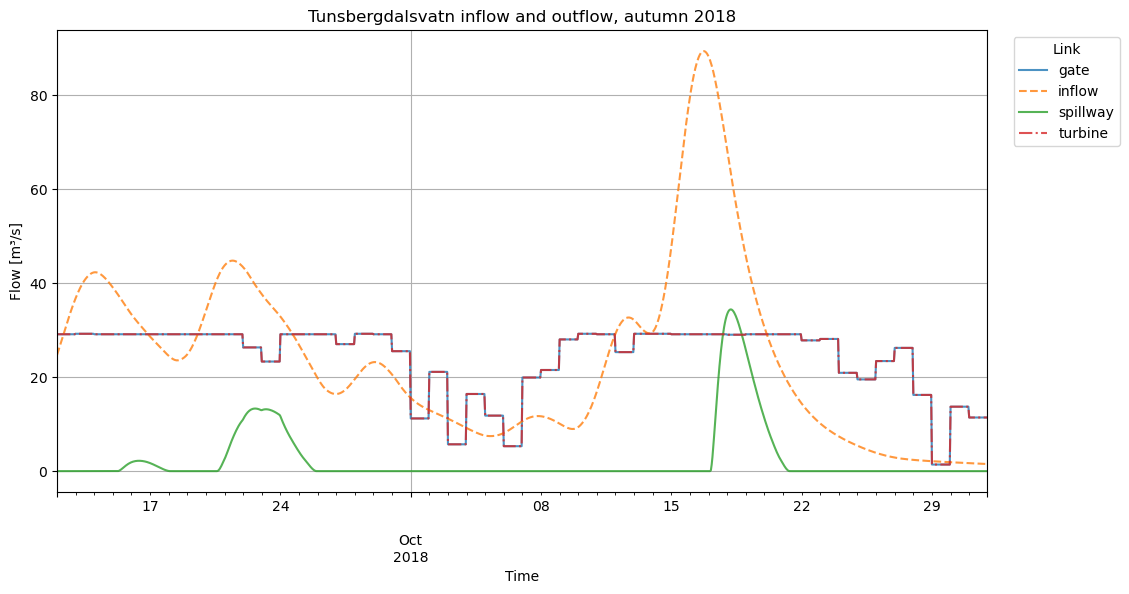

In [25]:
# Plot flow data
# Read the flow results
df_flow = pd.read_feather("Leirdøla_simple/results/flow.arrow")
# Add the link names and then remove unnamed links
df_flow["name"] = model.link.df["name"].loc[df_flow["link_id"]].to_numpy()
df_flow = df_flow[df_flow["name"].astype(bool)]

# Create a pivot table
pivot_flow = df_flow.pivot_table(index="time", columns="name", values="flow_rate")

line_styles = ["-", "--", "-", "-.", "-"]
num_styles = len(line_styles)

fig, ax = plt.subplots(figsize=(12, 6))
for i, column in enumerate(pivot_flow.columns):
    pivot_flow[column].plot(
        ax=ax, linestyle=line_styles[i % num_styles], linewidth=1.5, alpha=0.8
    )

# Set labels and title
ax.set_xlabel("Time")
ax.set_ylabel("Flow [m³/s]")
ax.legend(bbox_to_anchor=(1.15, 1), title="Link")
plt.title("Tunsbergdalsvatn inflow and outflow, autumn 2018")
plt.grid(True)
plt.show()

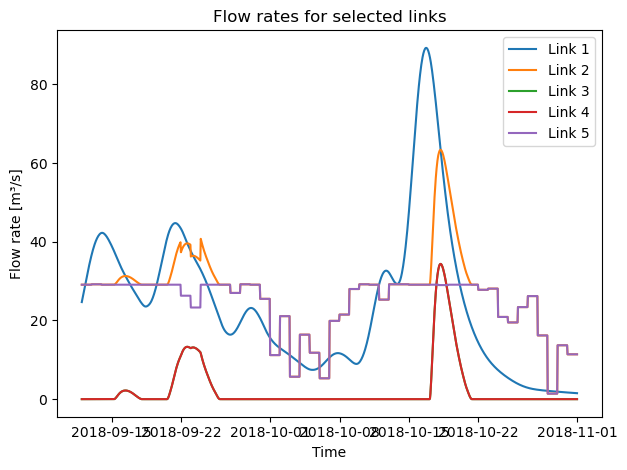

In [22]:
df_flow["time"] = pd.to_datetime(df_flow["time"])
df_sel = df_flow[df_flow["link_id"].isin([1,2,3,4,5])]


df_1 = df_sel[df_sel["link_id"] == 1]
df_2 = df_sel[df_sel["link_id"] == 2]
df_3 = df_sel[df_sel["link_id"] == 3]
df_4 = df_sel[df_sel["link_id"] == 4]
df_5 = df_sel[df_sel["link_id"] == 5]
plt.figure()
plt.plot(df_1["time"], df_1["flow_rate"], label="Link 1")
plt.plot(df_2["time"], df_2["flow_rate"], label="Link 2")
plt.plot(df_3["time"], df_3["flow_rate"], label="Link 3")
plt.plot(df_4["time"], df_4["flow_rate"], label="Link 4")
plt.plot(df_5["time"], df_5["flow_rate"], label="Link 5")

plt.xlabel("Time")
plt.ylabel("Flow rate [m³/s]")
plt.title("Flow rates for selected links")
plt.legend()
plt.tight_layout()
plt.show()


In [85]:
df_reservoir = pd.read_feather("Leirdøla_simple/results/basin.arrow")
df_reservoir.head()

,time,node_id,level,storage,inflow_rate,outflow_rate,storage_rate,precipitation,surface_runoff,evaporation,drainage,infiltration,balance_error,relative_error,convergence
0,2018-09-12,2,477.692000,9.162070e+07,30.707189,29.100002,1.607187,0.0,0.0,0.0,0.0,0.0,-6.661338e-16,-2.227604e-17,0.0
1,2018-09-13,2,477.710093,9.175956e+07,40.185860,29.199989,10.985871,0.0,0.0,0.0,0.0,0.0,1.776357e-15,5.120228e-17,0.0
2,2018-09-14,2,477.833749,9.270874e+07,41.186834,29.100000,12.086835,0.0,0.0,0.0,0.0,0.0,-3.552714e-15,-1.010919e-16,0.0
3,2018-09-15,2,477.969765,9.375304e+07,36.316363,29.100000,7.216363,0.0,0.0,0.0,0.0,0.0,1.776357e-15,5.430925e-17,0.0
4,2018-09-16,2,478.050955,9.437653e+07,30.980826,29.100000,1.880826,0.0,0.0,0.0,0.0,0.0,6.661338e-16,2.217459e-17,0.0


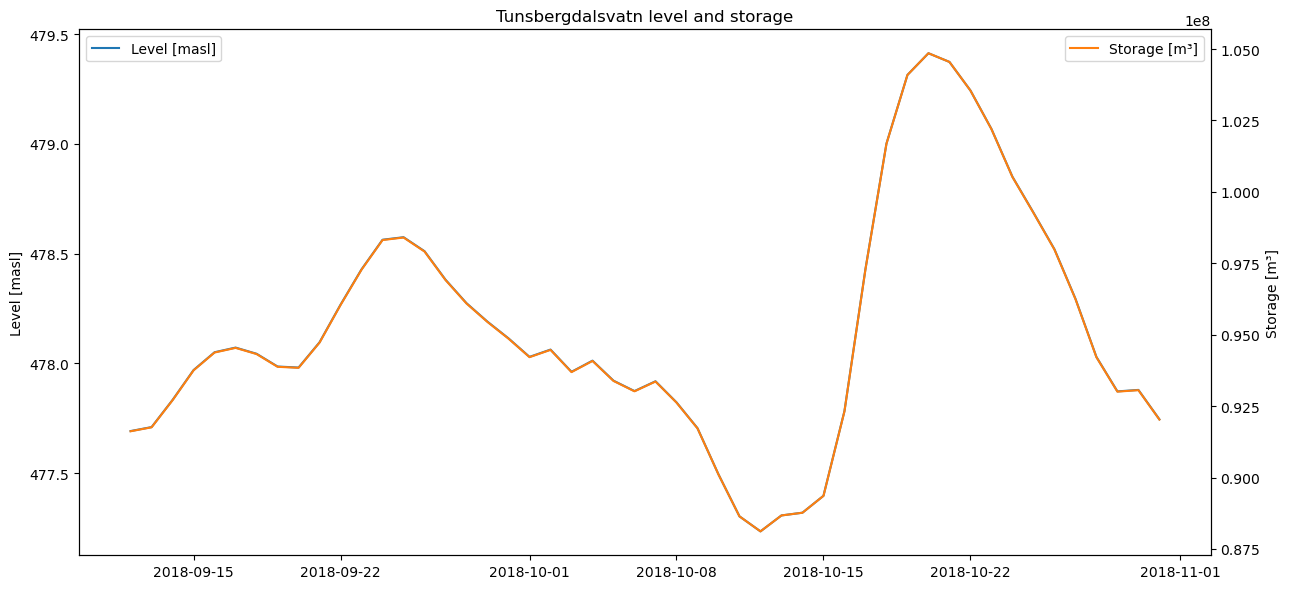

In [86]:
df_reservoir["time"] = pd.to_datetime(df_reservoir["time"])

fig, ax1 = plt.subplots(figsize=(13, 6))

# Level axis
ax1.plot(
    df_reservoir["time"],
    df_reservoir["level"],
    label="Level [masl]",
    color="tab:blue"
)
ax1.set_ylabel("Level [masl]")
ax1.legend(loc="upper left")

# Storage axis
ax2 = ax1.twinx()
ax2.plot(
    df_reservoir["time"],
    df_reservoir["storage"],
    label="Storage [m³]",
    color="tab:orange"
)
ax2.set_ylabel("Storage [m³]")
ax2.legend(loc="upper right")

plt.title("Tunsbergdalsvatn level and storage")
fig.tight_layout()
plt.show()


In [87]:
df_daily = pd.read_csv("tuns_vannstand.csv", sep=";", skiprows=1, decimal=",")
df_daily["Tidspunkt"] = pd.to_datetime(df_daily["Tidspunkt"])
df_daily.head()

,Tidspunkt,Vannstand (m),Korrigert,Kontrollert
0,2018-09-12 23:00:00+00:00,477.914,0,1
1,2018-09-13 23:00:00+00:00,478.006,0,1
2,2018-09-14 23:00:00+00:00,478.022,0,1
3,2018-09-15 23:00:00+00:00,477.960,0,1
4,2018-09-16 23:00:00+00:00,477.896,0,1


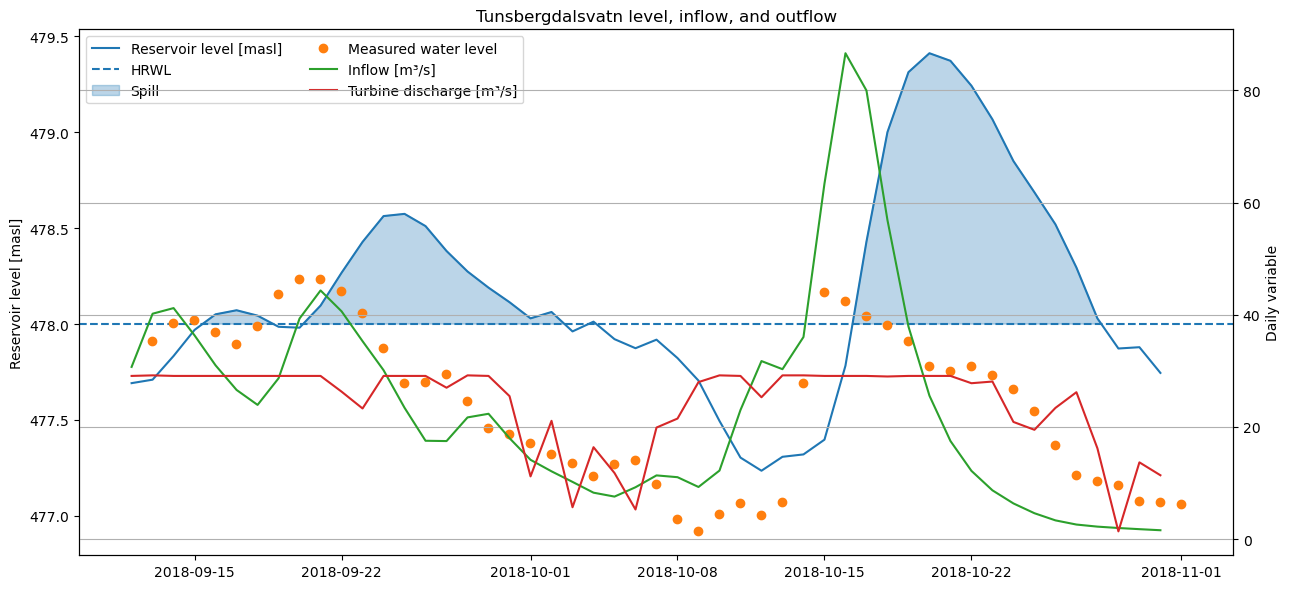

In [88]:
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(
    df_reservoir["time"],
    df_reservoir["level"],
    label="Reservoir level [masl]",
    color="tab:blue"
)
ax1.axhline(478, linestyle="--", c="tab:blue", label="HRWL")
ax1.fill_between(
    df_reservoir["time"],
    df_reservoir["level"],
    478,
    where=df_reservoir["level"] >= 478,
    color="tab:blue",
    alpha=0.3,
    interpolate=True,
    label="Spill"
)
ax1.set_ylabel("Reservoir level [masl]")

ax2 = ax1.twinx()
ax2.plot(
    df_reservoir["time"],
    df_reservoir["inflow_rate"],
    label="Inflow [m³/s]",
    color="tab:green"
)
ax2.plot(
    df_reservoir["time"],
    df_reservoir["outflow_rate"],
    label="Turbine discharge [m³/s]",
    color="tab:red"
)
ax2.set_ylabel("Discharge [m³/s]")


ax1.plot(
    df_daily["Tidspunkt"],
    df_daily["Vannstand (m)"],
    color="tab:orange",
    marker="o",
    linestyle="None",
    label="Measured water level"
)

ax2.set_ylabel("Daily variable")


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    ncol=2,          
    frameon=True
)
plt.title("Tunsbergdalsvatn level, inflow, and outflow")
fig.tight_layout()
plt.grid()
plt.show()
